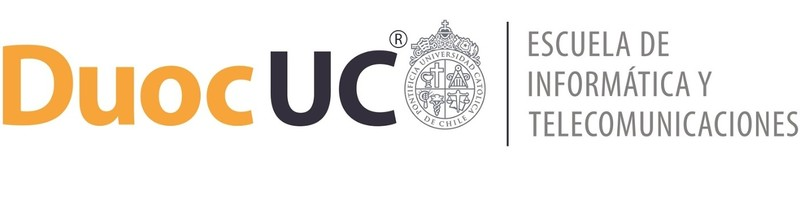

# Deep Learning 003D
* Profesor Marco Antonio Jakpe
* Grupo:6
* Antonia Barrera
* Ignacio Fernández
* Matias Meneses
* Luciano Acuna

#Contexto del caso

En esta actividad, vamos a trabajar con *Convolutional Neural Networks* para resolver un problema de clasificación de imágenes. En particular, vamos a clasificar imágenes de personajes de la conocida serie de los Simpsons.

El dataset a utilizar consiste en imágenes de personajes de los Simpsons extraídas directamente de capítulos de la serie. Este dataset ha sido recopilado por Alexandre Attia, Aparte de tener más clases (vamos a utilizar los 18 personajes con más imágenes), los personajes pueden aparecer en distintas poses, en distintas posiciones de la imagen o con otros personajes en pantalla (si bien el personaje a clasificar siempre aparece en la posición predominante).

#Cargar las librerias

In [ ]:
import cv2
import gdown
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import random
import seaborn as sns
import tarfile
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

# Configuración para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


#Carga del dataset

In [ ]:
# ============================================================
# INSTALAR GDOWN
# ============================================================

!pip install -q gdown

# ============================================================
# IMPORTAR LIBRERÍAS
# ============================================================

import gdown
import zipfile
import os
import tarfile # Importar la librería tarfile

# ============================================================
# LINK DE LA CARPETA DE GOOGLE DRIVE
# ============================================================

FOLDER_URL = "https://drive.google.com/drive/folders/1oKVVZY6ckWqV9KTurc61zwt9noR89cSw?usp=drive_link"

# Carpeta donde se descargarán los archivos
DOWNLOAD_PATH = "/content/dataset"

# ============================================================
# DESCARGAR TODOS LOS ARCHIVOS DE LA CARPETA
# ============================================================

gdown.download_folder(
    url=FOLDER_URL,
    output=DOWNLOAD_PATH,
    quiet=False,
    use_cookies=False
)

print("Datasets descargados correctamente.")

# ============================================================
# MOSTRAR LOS ARCHIVOS DESCARGADOS
# ============================================================

print("\nArchivos descargados:")
for archivo in os.listdir(DOWNLOAD_PATH):
    print("-", archivo)

# ============================================================
# EXTRAER TODOS LOS TAR.GZ
# ============================================================

for archivo in os.listdir(DOWNLOAD_PATH):
    if archivo.endswith(".tar.gz"):
        ruta_tar_gz = os.path.join(DOWNLOAD_PATH, archivo)

        with tarfile.open(ruta_tar_gz, "r:gz") as tar_ref:
            tar_ref.extractall("/content/")

        print(f"{archivo} extraído correctamente.")

print("\nTodos los datasets fueron extraídos.")

Retrieving folder contents


Processing file 1RjZgvEEvO8bARYGP124NicGL4yipKT-e simpsons_test.tar.gz
Processing file 1oGoplHKceDdB_AGKVX2WnBue_XZFl8nZ simpsons_train.tar.gz


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1RjZgvEEvO8bARYGP124NicGL4yipKT-e
To: /content/dataset/simpsons_test.tar.gz
100%|██████████| 10.7M/10.7M [00:00<00:00, 16.5MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1oGoplHKceDdB_AGKVX2WnBue_XZFl8nZ
From (redirected): https://drive.google.com/uc?id=1oGoplHKceDdB_AGKVX2WnBue_XZFl8nZ&confirm=t&uuid=19ffb26e-a22c-4560-96bd-72a5aa037acf
To: /content/dataset/simpsons_train.tar.gz
100%|██████████| 524M/524M [00:10<00:00, 49.6MB/s]
Download completed
/tmp/ipykernel_11355/2455275261.py:55: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar_ref.extractall("/content/")


Datasets descargados correctamente.

Archivos descargados:
- simpsons_train.tar.gz
- simpsons_test.tar.gz
simpsons_train.tar.gz extraído correctamente.
simpsons_test.tar.gz extraído correctamente.

Todos los datasets fueron extraídos.


En esta parte preparamos el entorno del trabajo. Primero, instalamos una herramienta para conectar con Google Drive y poder tener acceso a las imágenes de los Simpsons y definimos los enlaces de los archivos. Después de descargar los paquetes comprimidos, el código se encarga de extraer todas las imágenes automáticamente para que queden listas para usarse en el notebook.



# Etiqueta de los personajes de los Simpsons

In [ ]:
# Esta variable contiene un mapeo de número de clase a personaje.
# Utilizamos sólo los 18 personajes del dataset que tienen más imágenes.
MAP_CHARACTERS = {
    0: 'abraham_grampa_simpson',
    1: 'apu_nahasapeemapetilon',
    2: 'bart_simpson',
    3: 'charles_montgomery_burns',
    4: 'chief_wiggum',
    5: 'comic_book_guy',
    6: 'edna_krabappel',
    7: 'homer_simpson',
    8: 'kent_brockman',
    9: 'krusty_the_clown',
    10: 'lisa_simpson',
    11: 'marge_simpson',
    12: 'milhouse_van_houten',
    13: 'moe_szyslak',
    14: 'ned_flanders',
    15: 'nelson_muntz',
    16: 'principal_skinner',
    17: 'sideshow_bob'
}

# Vamos a standarizar todas las imágenes a tamaño 64x64
IMG_SIZE = 64

En este paso, definimos las categorías y el formato de las imágenes. Primero, creamos un diccionario que asigna un número a cada uno de los 18 personajes con más datos, lo que facilita el trabajo del modelo. Además, establecemos que todas las imágenes tengan un tamaño estándar de 64x64 píxeles para que el entrenamiento sea uniforme y más eficiente.


In [ ]:
def load_train_set(dirname, map_characters, verbose=True):
    """Esta función carga los datos de training en imágenes.

    Como las imágenes tienen tamaños distintas, utilizamos la librería opencv
    para hacer un resize y adaptarlas todas a tamaño IMG_SIZE x IMG_SIZE.

    Args:
        dirname: directorio completo del que leer los datos
        map_characters: variable de mapeo entre labels y personajes
        verbose: si es True, muestra información de las imágenes cargadas

    Returns:
        X, y: X es un array con todas las imágenes cargadas con tamaño
                IMG_SIZE x IMG_SIZE
              y es un array con las labels de correspondientes a cada imagen
    """
    X_train = []
    y_train = []
    for label, character in map_characters.items():
        files = os.listdir(os.path.join(dirname, character))
        images = [file for file in files if file.endswith("jpg")]
        if verbose:
          print("Leyendo {} imágenes encontradas de {}".format(len(images), character))
        for image_name in images:
            image = cv2.imread(os.path.join(dirname, character, image_name))
            X_train.append(cv2.resize(image,(IMG_SIZE, IMG_SIZE)))
            y_train.append(label)
    return np.array(X_train), np.array(y_train)

In [ ]:
def load_test_set(dirname, map_characters, verbose=True):
    """Esta función funciona de manera equivalente a la función load_train_set
    pero cargando los datos de test."""
    X_test = []
    y_test = []
    reverse_dict = {v: k for k, v in map_characters.items()}
    for filename in glob.glob(dirname + '/*.*'):
        char_name = "_".join(filename.split('/')[-1].split('_')[:-1])
        if char_name in reverse_dict:
            image = cv2.imread(filename)
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            X_test.append(image)
            y_test.append(reverse_dict[char_name])
    if verbose:
        print("Leídas {} imágenes de test".format(len(X_test)))
    return np.array(X_test), np.array(y_test)


In [ ]:


# --- EL ARREGLO ESTÁ AQUÍ ---
# Reemplazamos las rutas locales (que están vacías) por las de tu Drive que si funcionan
DATASET_TRAIN_PATH_COLAB = "/content/simpsons"
DATASET_TEST_PATH_COLAB = "/content/simpsons_testset" # Corregido a la ruta correcta

# Ejecutamos la carga con las rutas de tu Drive
# Asegúrate de haber ejecutado las celdas donde definiste load_train_set y MAP_CHARACTERS antes de esto
X, y = load_train_set(DATASET_TRAIN_PATH_COLAB, MAP_CHARACTERS)
X_t, y_t = load_test_set(DATASET_TEST_PATH_COLAB, MAP_CHARACTERS)

# Verificación
print(f"\n {len(X)} imágenes de entrenamiento y {len(X_t)} de test.")

Leyendo 913 imágenes encontradas de abraham_grampa_simpson
Leyendo 623 imágenes encontradas de apu_nahasapeemapetilon
Leyendo 1342 imágenes encontradas de bart_simpson
Leyendo 1193 imágenes encontradas de charles_montgomery_burns
Leyendo 986 imágenes encontradas de chief_wiggum
Leyendo 469 imágenes encontradas de comic_book_guy
Leyendo 457 imágenes encontradas de edna_krabappel
Leyendo 2246 imágenes encontradas de homer_simpson
Leyendo 498 imágenes encontradas de kent_brockman
Leyendo 1206 imágenes encontradas de krusty_the_clown
Leyendo 1354 imágenes encontradas de lisa_simpson
Leyendo 1291 imágenes encontradas de marge_simpson
Leyendo 1079 imágenes encontradas de milhouse_van_houten
Leyendo 1452 imágenes encontradas de moe_szyslak
Leyendo 1454 imágenes encontradas de ned_flanders
Leyendo 358 imágenes encontradas de nelson_muntz
Leyendo 1194 imágenes encontradas de principal_skinner
Leyendo 877 imágenes encontradas de sideshow_bob
Leídas 890 imágenes de test

 18992 imágenes de entren

Con las imágenes ya preparadas en el entorno, procedemos a realizar un balance del dataset mediante un conteo por categorías. El objetivo es poder identificar la cantidad de imágenes disponibles por cada personaje, esto es para asegurar que el modelo aprenda de forma equitativa y para tener un control total sobre el volumen de datos con el que estaremos experimentando en las siguientes fases del proyecto.

In [ ]:
# Vamos a barajar aleatoriamente los datos. Esto es importante ya que si no
# lo hacemos y, por ejemplo, cogemos el 20% de los datos finales como validation
# set, estaremos utilizando solo un pequeño número de personajes, ya que
# las imágenes se leen secuencialmente personaje a personaje.
perm = np.random.permutation(len(X))
X, y = X[perm], y[perm]

#Vistazo previo de las imágenes

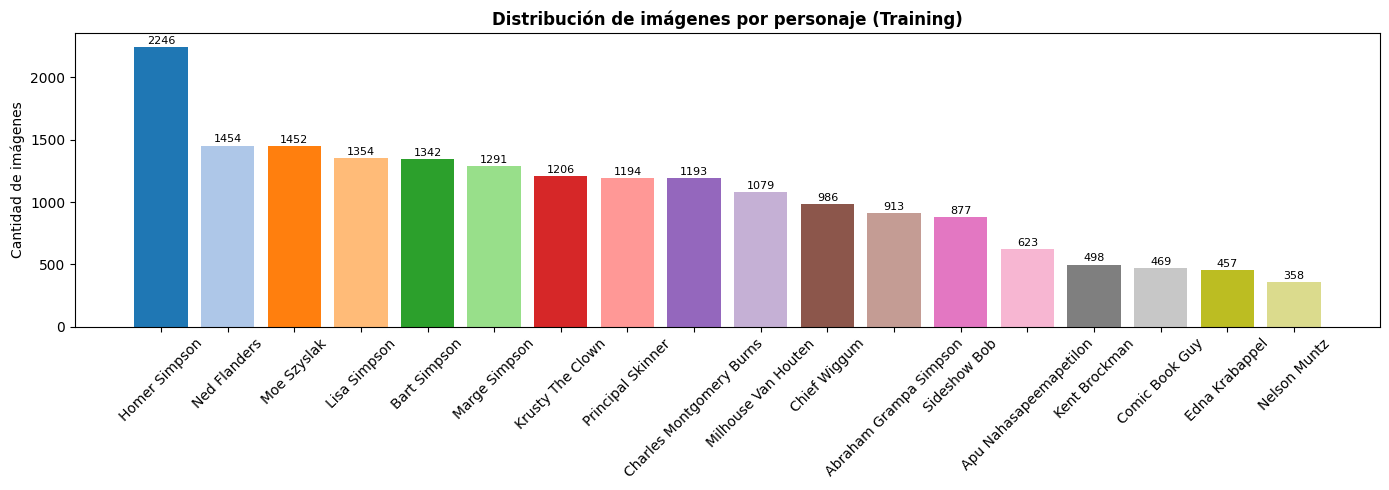

Total train: 18992 | Max: 2246 | Min: 358


In [ ]:
# Visualizamos la distribución de imágenes por personaje
# para detectar si hay desbalance de clases
counts = {MAP_CHARACTERS[i]: int(np.sum(y == i)) for i in range(len(MAP_CHARACTERS))}
sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)

fig, ax = plt.subplots(figsize=(14, 5))
nombres = [x[0].replace('_', ' ').title() for x in sorted_counts]
valores = [x[1] for x in sorted_counts]
bars = ax.bar(nombres, valores, color=plt.cm.tab20.colors)
for bar, v in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height()+10,
            str(v), ha='center', va='bottom', fontsize=8)
ax.set_title('Distribución de imágenes por personaje (Training)', fontweight='bold')
ax.set_ylabel('Cantidad de imágenes')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(f'Total train: {len(X)} | Max: {max(valores)} | Min: {min(valores)}')


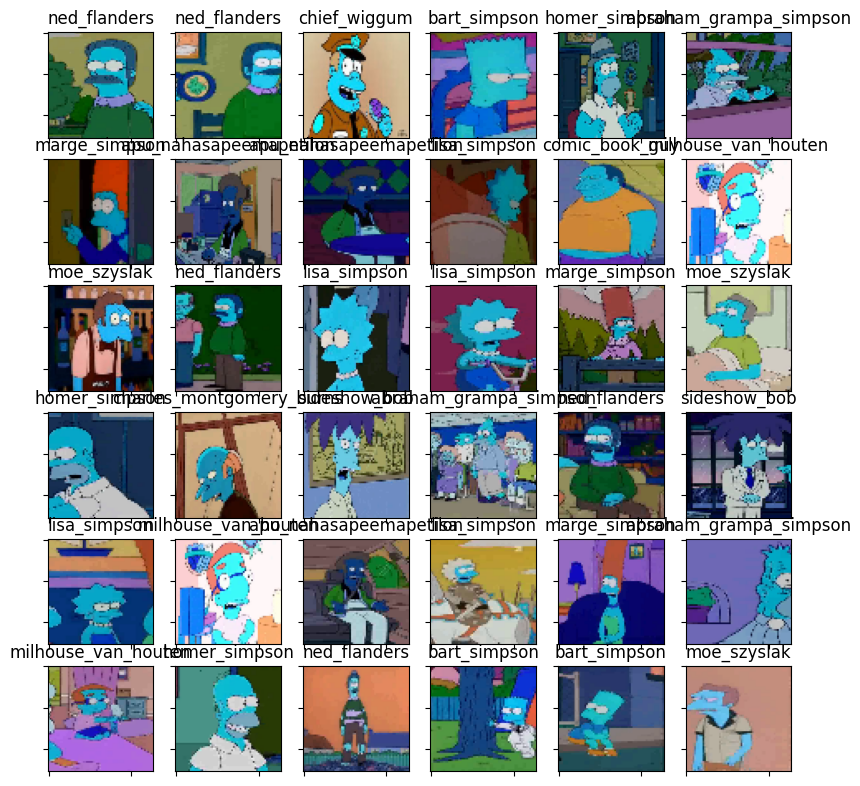

In [ ]:
# Mostramos una grilla de ejemplos (al azar) del conjunto de test

h = 6 # alto de la grilla
w = 6 # ancho de la grilla
fig, axs = plt.subplots(h, w, figsize=(1.6*h,1.6*w))
for i in range(h):
  for j in range(w):
    #el ex hace que cada que recages la imagenes sean aleatorias
    ex = np.random.randint(len(X))
    axs[i,j].set_title(MAP_CHARACTERS[y[ex]])
    axs[i,j].grid(False)
    axs[i,j].set_xticklabels([])
    axs[i,j].set_yticklabels([])
    axs[i,j].imshow(X[ex])

#Elaboración de las arquitecturas


In [ ]:
input_shape=(64, 64, 3)

In [ ]:
num_clases = len(MAP_CHARACTERS)
print('num_clases')

num_clases


Antes de elaborar se configura las imagenes par que las arquitectura, tranformando las imagenes en 64X64 pixeles y con un RGB de 3 colores que son los primarios.

## Primera Arquitectura: Simple

In [ ]:
LEARNING_RATE = 0.001 # Define el learning rate
num_clases = len(MAP_CHARACTERS)

modelo_base = models.Sequential([
    layers.Input(shape=(64, 64, 3)),

    # Bloque 1: aprende patrones simples como bordes y colores
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Bloque 2: aprende formas más específicas
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Bloque 3: aprende detalles más complejos del personaje
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Conversión de mapas de características a vector
    layers.Flatten(),

    # Capa densa para la clasificación
    layers.Dense(256, activation='relu'),

    # Regularización para reducir memorización/overfitting
    layers.Dropout(0.5),

    # Salida: una neurona por personaje
    layers.Dense(num_clases, activation='softmax')
])

modelo_base.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

modelo_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 18)             │         4,626 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,195,282 (8.37 MB)

 Trainable params: 2,195,282 (8.37 MB)

 Non-trainable params: 0 (0.00 B)


Para el primer modelo se implementó la primera arquitectura de red neuronal convolucional *(CNN)* como modelo base, la cual fue diseñada para extraer características relevantes de las imágenes de los personajes de Los Simpsons.
Las imágenes fueron redimensionadas a 64x64 píxeles para reducir el costo computacional. Posteriormente, se aplicaron capas convolucionales con distintos filtros, los cuales permiten extraer características relevantes de las imágenes durante el entrenamiento del modelo

Esta arquitectura está compuesta por tres bloques convolucionales:

- El primer bloque utiliza 32 filtros, permitiendo detectar características simples como bordes y colores.
- El segundo bloque aumenta a 64 filtros, lo que permite identificar patrones más complejos.
- El tercer bloque utiliza 128 filtros, capturando detalles más específicos de los personajes.

Cada bloque incluye una capa de MaxPooling, que reduce la dimensionalidad de la imagen y permite enfocarse en las características más importantes.

Posteriormente, se utiliza una capa Flatten para transformar los datos en un vector, el cual es procesado por una capa densa de 256 neuronas. Esta capa permite aprender combinaciones más complejas de las características extraídas.

Se incorpora una capa Dropout con una tasa de 0.5, con el objetivo de reducir el overfitting, evitando que el modelo memorice las imágenes de entrenamiento y mejorando su capacidad de generalización y se utiliza una capa de salida con activación Softmax, que permite clasificar cada imagen en una de las clases correspondientes a los personajes del dataset.

----------------------------------------------------------------------------------------------

##Segunda Arquitectura: ResNet

In [ ]:
# Bloque residual
def residual_block(x, filters):
    shortcut = x

    # Primera convolución
    x = layers.Conv2D(filters, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # Segunda convolución
    x = layers.Conv2D(filters, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)

    # Ajustar dimensiones si es necesario
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), padding='same')(shortcut)

    # Conexión residual
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)

    return x


# Entrada
inputs = layers.Input(shape=(64, 64, 3))

# Bloque inicial
x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

# Bloques residuales
x = residual_block(x, 32)
x = layers.MaxPooling2D((2, 2))(x)

x = residual_block(x, 64)
x = layers.MaxPooling2D((2, 2))(x)

x = residual_block(x, 128)
x = layers.MaxPooling2D((2, 2))(x)

# Clasificación
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(num_clases, activation='softmax')(x)

modelo_resnet = Model(inputs, outputs)

modelo_resnet.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

modelo_resnet.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │      9,248 │ max_pooling2d_3[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32, 32,    │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 16, 16,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │      2,112 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 16, 16,    │          0 │ batch_normalizat

 Total params: 837,778 (3.20 MB)

 Trainable params: 836,818 (3.19 MB)

 Non-trainable params: 960 (3.75 KB)


La arquitectura ResNet fue implementada con el objetivo de mejorar el aprendizaje de características complejas en las imágenes mediante el uso de bloques residuales. A diferencia de una CNN tradicional, ResNet incorpora conexiones residuales o “shortcuts”, las cuales permiten reutilizar información de capas anteriores y evitar la pérdida de información durante el entrenamiento.

La arquitectura procesa las imágenes utilizando capas convolucionales encargadas de detectar patrones visuales, junto con BatchNormalization para estabilizar el aprendizaje y MaxPooling para reducir la dimensionalidad de las imágenes, Posteriormente, las características extraídas son transformadas en vectores mediante la capa Flatten y clasificadas utilizando capas densas con función de activación Softmax.

## Tercera Arquitectura: Plain net

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

LEARNING_RATE = 1e-4 # Define LEARNING_RATE


modelo_plainnet = models.Sequential([
    # Bloque 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25), # Regularización temprana para evitar dispersión

    # Bloque 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Bloque 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),


    # En lugar de un Flatten abrupto, usamos GlobalAveragePooling2D o aumentamos la capa densa
    layers.GlobalAveragePooling2D(),

    # Clasificación con mejor capacidad de relacionar datos
    layers.Dense(512, activation='relu'), # Incrementado de 256 a 512 para mayor plasticidad
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    # Salida
    layers.Dense(num_clases, activation='softmax')
])

modelo_plainnet.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE), # Asegúrate de que el LR no sea muy alto (ej. 1e-4 o 2e-4)
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

modelo_plainnet.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 366,130 (1.40 MB)

 Trainable params: 364,210 (1.39 MB)

 Non-trainable params: 1,920 (7.50 KB)

En la mejora de la arquitectura plaintet se alteraron algunas parte del código para que tenga un mejor rendimiento, las cuales fue reemplazar la capa Flatten() por GlobalAveragePooling2D() lo que redujo los niveles de parámetros, pasando de 827.346 a 366.130, también se incorporo el dropout después de cada bloque convolucional y se llego a aumentar la capa densa de 256 a 512 neuronas, y por último se agregó el BatchNormalization para poder estabilizar el entrenamiento.


# Entrenamiento de las arquitecturas

##Entrenamiento Modelo 1

In [ ]:
# ============================================================
# ENTRENAMIENTO MODELO PROPIO / BASE
# ============================================================

# Callbacks para entrenamiento (re-definidas para evitar NameError)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001)

# Función para obtener las callbacks (re-definida)
def get_callbacks():
    return [early_stopping, reduce_lr]

# División de datos en entrenamiento y validación (si no se ha hecho ya)
# Se asume que X y y ya están cargados y preprocesados
# Si X_scaled y X_t_scaled no existen, se deberían crear primero.
# Para este ejemplo, se usará X_scaled y se creará y_train, X_val, y_val

# Aseguramos que X_scaled y X_t_scaled existan y estén escalados
if 'X_scaled' not in locals() or 'X_scaled' not in globals():
    X_scaled = X.astype('float32') / 255.0
if 'X_t_scaled' not in locals() or 'X_t_scaled' not in globals():
    X_t_scaled = X_t.astype('float32') / 255.0

# Dividir el conjunto de entrenamiento en entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=SEED)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de X_val: {X_val.shape}")
print(f"Dimensiones de y_val: {y_val.shape}")
print(f"Dimensiones de X_t_scaled: {X_t_scaled.shape}")
print(f"Dimensiones de y_t: {y_t.shape}")

history_base = modelo_base.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks()
)

Dimensiones de X_train: (15193, 64, 64, 3)
Dimensiones de y_train: (15193,)
Dimensiones de X_val: (3799, 64, 64, 3)
Dimensiones de y_val: (3799,)
Dimensiones de X_t_scaled: (890, 64, 64, 3)
Dimensiones de y_t: (890,)
Epoch 1/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.3475 - loss: 2.1088 - val_accuracy: 0.5862 - val_loss: 1.3245 - learning_rate: 0.0010
Epoch 2/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6083 - loss: 1.2909 - val_accuracy: 0.7299 - val_loss: 0.9151 - learning_rate: 0.0010
Epoch 3/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7181 - loss: 0.9232 - val_accuracy: 0.7760 - val_loss: 0.7610 - learning_rate: 0.0010
Epoch 4/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7851 - loss: 0.6862 - val_accuracy: 0.8255 - val_loss: 0.6158 - learning_rate: 0.0010
Epoch 5/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8405 - loss: 0.5127 - val_accuracy: 0.8452 - val_loss: 0.5692 - learning_rate: 0.0010
Epoch 6/50
475/475 ━━



En el primer modelo a desarrollar se decidio ocupar la primera arquitectura el modelo presento una mejora progesica en el entrenamiento llegando a alcanzar un acurracy de 99% en entrenamiento y un aproximado del 89%de validacion al llegar a la epoca 23, en la cual se detiene debido a que al superar esta cantidad de entrenamiento por epoca llega al overfitin.

Laisminución constante de la loss indica que la red logró aprender patrones relevantes del dataset.

Sin embargo, se observa una diferencia entre el rendimiento de entrenamiento y validación, indicando un leve overfitting hacia las últimas épocas. A pesar de esto, el modelo mantuvo una capacidad de generalización adecuada.Además, la reducción progresiva del learning rate permitió realizar ajustes más finos durante las etapas finales del entrenamiento, contribuyendo a la estabilidad del modelo.

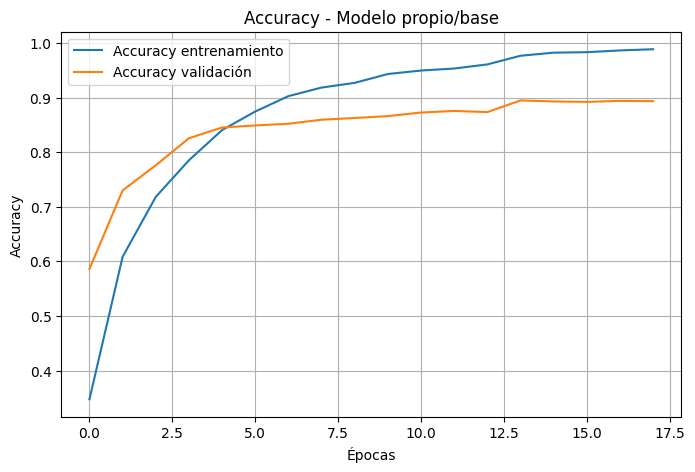

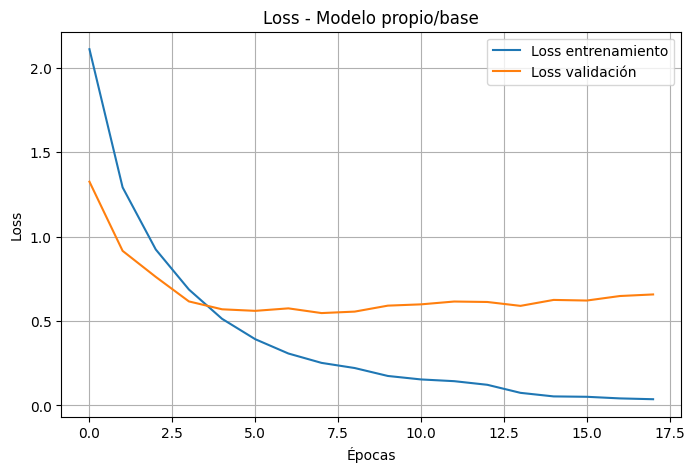

In [ ]:
# ============================================================
# GRÁFICOS MODELO PROPIO / BASE
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history_base.history['accuracy'], label='Accuracy entrenamiento')
plt.plot(history_base.history['val_accuracy'], label='Accuracy validación')
plt.title('Accuracy - Modelo propio/base')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_base.history['loss'], label='Loss entrenamiento')
plt.plot(history_base.history['val_loss'], label='Loss validación')
plt.title('Loss - Modelo propio/base')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

El gráfico de accuracy muestra que el modelo logró aprender correctamente durante el entrenamiento, alcanzando un accuracy cercano al 99% en entrenamiento y aproximadamente un 89% en validación.

La curva de validación presenta un comportamiento estable, indicando una buena capacidad de generalización sobre datos no vistos. Sin embargo, se observa una pequeña diferencia entre ambas curvas hacia las últimas épocas, lo que sugiere un leve sobreajuste del modelo. A pesar de ello, el uso de Dropout permitió reducir parcialmente el overfitting y mantener un rendimiento estable en validación.

In [ ]:
X_t_scaled = X_t.astype('float32') / 255.0

loss_base, accuracy_base = modelo_base.evaluate(X_t_scaled, y_t, verbose=0)

y_pred_probs_base = modelo_base.predict(X_t_scaled)
y_pred_base = np.argmax(y_pred_probs_base, axis=1)

precision_base = precision_score(y_t, y_pred_base, average='weighted', zero_division=0)
recall_base = recall_score(y_t, y_pred_base, average='weighted', zero_division=0)
f1_base = f1_score(y_t, y_pred_base, average='weighted', zero_division=0)

resultados_base = pd.DataFrame([{
    "Modelo": "Modelo propio/base",
    "Loss": loss_base,
    "Accuracy": accuracy_base,
    "Precision": precision_base,
    "Recall": recall_base,
    "F1-score": f1_base
}])

resultados_base

28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step


,Modelo,Loss,Accuracy,Precision,Recall,F1-score
0,Modelo propio/base,0.177305,0.959551,0.961887,0.959551,0.959769


Tras el entrenamiento por epocas, se dio

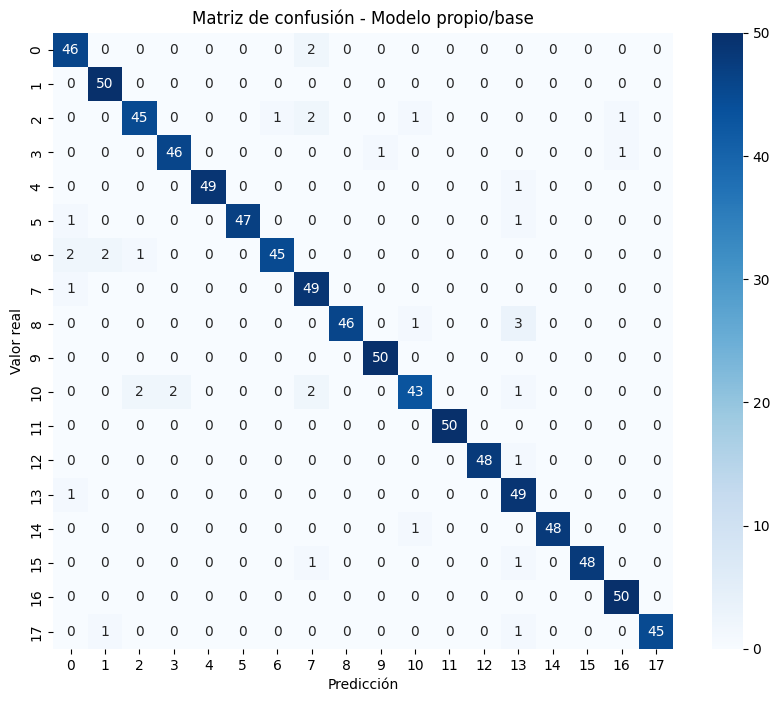

In [ ]:


cm_base = confusion_matrix(y_t, y_pred_base)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_base, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión - Modelo propio/base")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

En la matriz de confusión muestra que el modelo logró clasificar correctamente la mayoría de las clases, observándose una alta concentración de valores en la diagonal principal. Esto indica un buen rendimiento general en la identificación de personajes del dataset.

Los errores de clasificación fueron bajos y se presentaron únicamente en algunas clases específicas, posiblemente debido a similitudes visuales entre ciertos personajes. En general, el modelo demostró una adecuada capacidad de generalización y reconocimiento de patrones.

##Entrenamiento Modelo 2

In [ ]:
# ============================================================
# RESUMEN DEL MODELO 2: RESNET
# ============================================================

modelo_resnet.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │      9,248 │ max_pooling2d_3[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32, 32,    │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 16, 16,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │      2,112 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 16, 16,    │          0 │ batch_normalizat

 Total params: 837,778 (3.20 MB)

 Trainable params: 836,818 (3.19 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# ============================================================
# ENTRENAMIENTO MODELO 3: RESNET
# ============================================================

history_resnet = modelo_resnet.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks()
)

Epoch 1/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 29s 38ms/step - accuracy: 0.2999 - loss: 2.3051 - val_accuracy: 0.4180 - val_loss: 1.9129 - learning_rate: 0.0010
Epoch 2/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6308 - loss: 1.2216 - val_accuracy: 0.7191 - val_loss: 0.9476 - learning_rate: 0.0010
Epoch 3/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7754 - loss: 0.7443 - val_accuracy: 0.8268 - val_loss: 0.6009 - learning_rate: 0.0010
Epoch 4/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8447 - loss: 0.5175 - val_accuracy: 0.7928 - val_loss: 0.7330 - learning_rate: 0.0010
Epoch 5/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8873 - loss: 0.3770 - val_accuracy: 0.8476 - val_loss: 0.5329 - learning_rate: 0.0010
Epoch 6/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9407 - loss: 0.2022 - val_accuracy: 0.9073 - val_loss: 0.3375 - learning_rate: 2.0000e-04
Epoch 7/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9612 - los

A diferencia del entrenamiento de la anterior arquitectura, el modelo que utilizo la arquitectura Restnet llego al cual obtuvo un buen rendimiento, alcanzando un accuracy cercano al 95% y un F1-score de 0.95, lo que indica una adecuada capacidad de clasificación y equilibrio entre precision y recall.

Además se pede analisar que hubo una baja pérdida obtenida demuestra que el modelo logró minimizar correctamente los errores durante el proceso de entrenamiento y evaluación.

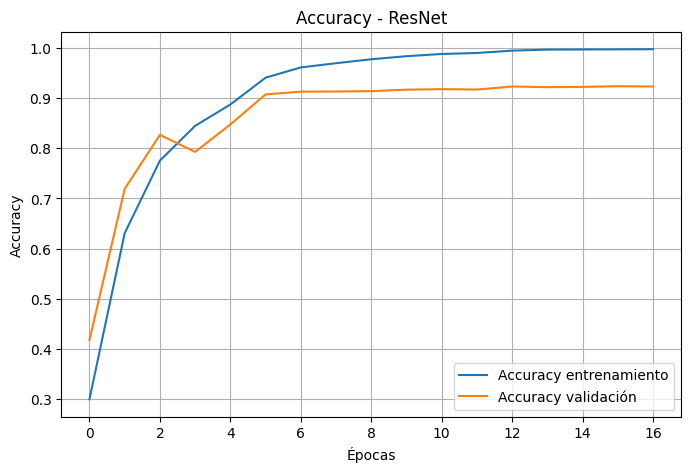

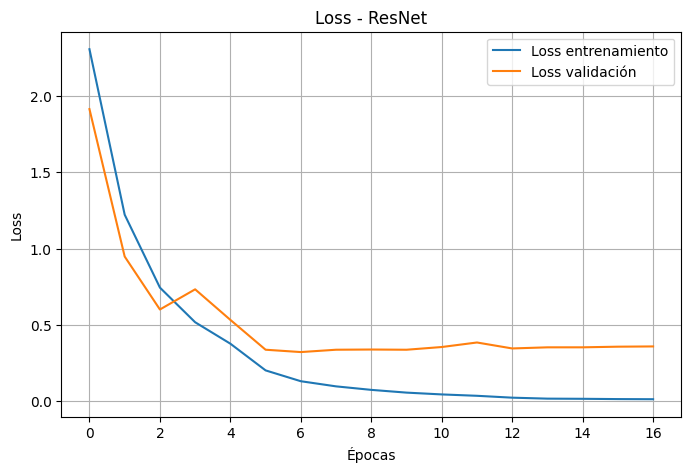

In [ ]:
# ============================================================
# GRÁFICO DE ACCURACY - RESNET
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history_resnet.history['accuracy'], label='Accuracy entrenamiento')
plt.plot(history_resnet.history['val_accuracy'], label='Accuracy validación')
plt.title('Accuracy - ResNet')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# GRÁFICO DE LOSS - RESNET
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history_resnet.history['loss'], label='Loss entrenamiento')
plt.plot(history_resnet.history['val_loss'], label='Loss validación')
plt.title('Loss - ResNet')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

En el grafico s puede apreciar que la perdida logra llegar mas rapido en la epoca 5 en donde el error disminuye,.

A partir de la época 5, la curva de validación se estabiliza cerca de 0.4 aproximadamente, mientras que la de entrenamiento sigue bajando significando  que Esto refleja un overfitin ligero; el modelo se especializa en los datos de entrenamiento, pero mantiene un rendimiento constante en validación sin degradarse.

In [ ]:
# ============================================================
# EVALUACIÓN MODELO 3: RESNET
# ============================================================

loss_resnet, accuracy_resnet = modelo_resnet.evaluate(
    X_t_scaled,
    y_t,
    verbose=0
)

y_pred_probs_resnet = modelo_resnet.predict(X_t_scaled)
y_pred_resnet = np.argmax(y_pred_probs_resnet, axis=1)

precision_resnet = precision_score(
    y_t,
    y_pred_resnet,
    average='weighted',
    zero_division=0
)

recall_resnet = recall_score(
    y_t,
    y_pred_resnet,
    average='weighted',
    zero_division=0
)

f1_resnet = f1_score(
    y_t,
    y_pred_resnet,
    average='weighted',
    zero_division=0
)

resultados_resnet = pd.DataFrame([{
    "Modelo": "ResNet",
    "Loss": loss_resnet,
    "Accuracy": accuracy_resnet,
    "Precision": precision_resnet,
    "Recall": recall_resnet,
    "F1-score": f1_resnet
}])

resultados_resnet

28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step


,Modelo,Loss,Accuracy,Precision,Recall,F1-score
0,ResNet,0.186572,0.939326,0.945952,0.939326,0.939628


En el analissi del entrenamiento se logro apreciar que el modelo 2 elaborado con la arquitectura restnet lo cual mostro un rendimiento superior en comparación con el modelo base, alcanzando una precisión cercana al 99% en entrenamiento y aproximadamente un 93% en validación.

La disminución progresiva de la loss indica que el modelo logró aprender patrones complejos del dataset de manera efectiva. Además, las conexiones residuales permitieron mantener un entrenamiento más estable y mejorar la capacidad de generalización del modelo, Aunque se observa una ligera diferencia entre entrenamiento y validación, el modelo mantuvo un comportamiento estable, evidenciando un overfitting leve y controlado.

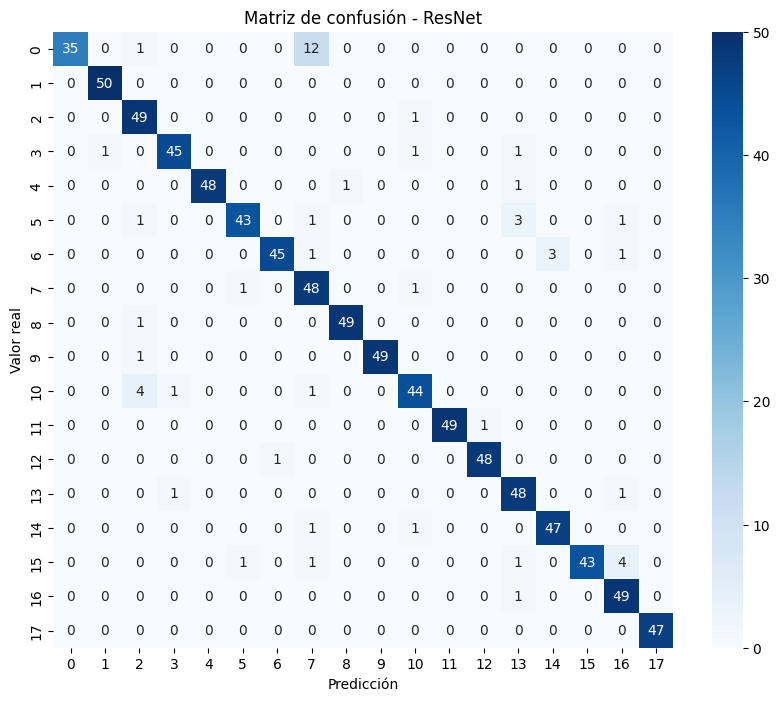

In [ ]:
cm_resnet = confusion_matrix(y_t, y_pred_resnet)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_resnet, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión - ResNet")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

En la matriz de confucion nos muestra un alto desempeño del con una diagonal principal muy marcada que indica una clasificación correcta en la gran mayoría de las 18 categorías. El modelo logra precisiones perfectas o casi perfectas en clases como la 1, 9 y 11, donde se alcanzan los 50 aciertos posibles.

Se observan confusiones menores y dispersas, como en la clase 0, donde 4 muestras fueron clasificadas erróneamente como clase 7. Sin embargo, estos errores son mínimos en comparación con el volumen de aciertos.

##Entrenamiento Modelo 3

In [ ]:
# ============================================================
# RESUMEN DEL MODELO 3: PLAINNET
# ============================================================

modelo_plainnet.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 366,130 (1.40 MB)

 Trainable params: 364,210 (1.39 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Callbacks para entrenamiento
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001)

# Función para obtener las callbacks
def get_callbacks():
    return [early_stopping, reduce_lr]

# Aseguramos que X_scaled exista y esté escalado
X_scaled = X.astype('float32') / 255.0

# Dividir el conjunto de entrenamiento en entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=SEED)

# ============================================================
# ENTRENAMIENTO MODELO 3: PLAINNET
# ============================================================

history_plainnet = modelo_plainnet.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks()
)

Epoch 1/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - accuracy: 0.1708 - loss: 3.0268 - val_accuracy: 0.1050 - val_loss: 3.4282 - learning_rate: 1.0000e-04
Epoch 2/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.2974 - loss: 2.4428 - val_accuracy: 0.2695 - val_loss: 2.7839 - learning_rate: 1.0000e-04
Epoch 3/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.4068 - loss: 2.0410 - val_accuracy: 0.3614 - val_loss: 2.3509 - learning_rate: 1.0000e-04
Epoch 4/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.4980 - loss: 1.7224 - val_accuracy: 0.4722 - val_loss: 1.8683 - learning_rate: 1.0000e-04
Epoch 5/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.5759 - loss: 1.4379 - val_accuracy: 0.5204 - val_loss: 1.7011 - learning_rate: 1.0000e-04
Epoch 6/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.6390 - loss: 1.2226 - val_accuracy: 0.5633 - val_loss: 1.6114 - learning_rate: 1.0000e-04
Epoch 7/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - ac

En el tercer entrenamiento en el cual utilizamos el modelo plainet, en el cual se logro observar que el modelo tubo un crecimiento progresivo hasta la epoca 40 en el cual aun que el accuracy se mantibo en un 97% aproximadamente, por otro lado la perdida (loss) se mantubo disminuyendo gradualmete



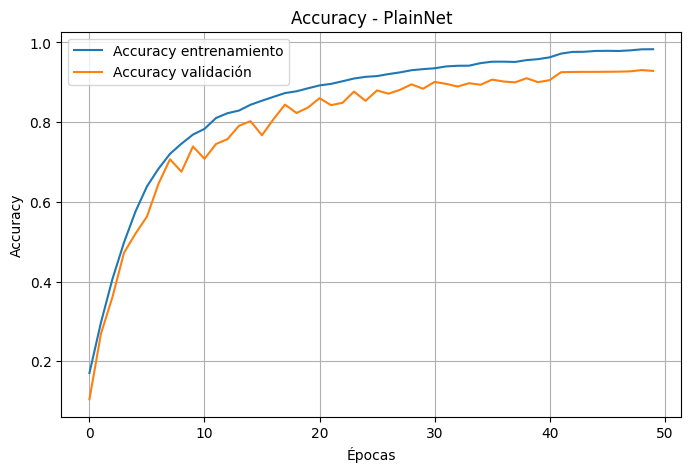

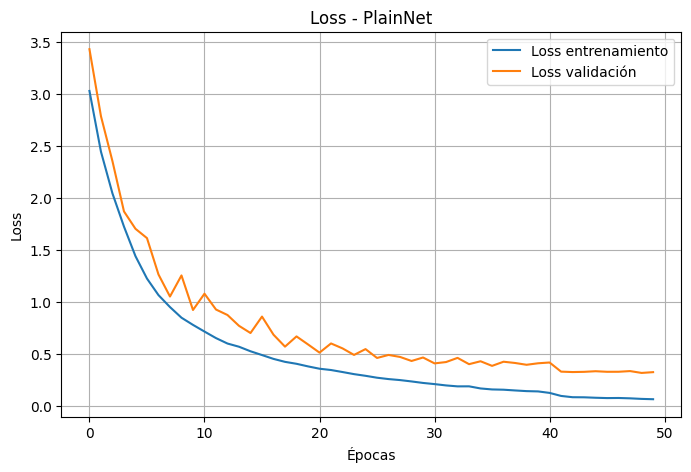

In [ ]:
# ============================================================
# GRÁFICO DE ACCURACY - PLAINNET
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history_plainnet.history['accuracy'], label='Accuracy entrenamiento')
plt.plot(history_plainnet.history['val_accuracy'], label='Accuracy validación')
plt.title('Accuracy - PlainNet')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# GRÁFICO DE LOSS - PLAINNET
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history_plainnet.history['loss'], label='Loss entrenamiento')
plt.plot(history_plainnet.history['val_loss'], label='Loss validación')
plt.title('Loss - PlainNet')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

durante las primera épocas se logra observar que el modelo aprende exponencialmente pero entre la época 9 y 10 el modelo empieza a decaer levemente en la época 10 pero se ajusta de a poco en entre las épocas 25 y 30, manteniendo una leve estabilidad.

En el loss el modelo logro mantener la perdida de una forma continua en las épocas, la curva  de validación se presenta con algunas alteraciones que se estabiliza por en la época 40 en donde logra estabilizarse


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score

# Asegurar que X_t_scaled esté definido
X_t_scaled = X_t.astype('float32') / 255.0

# ============================================================
# EVALUACIÓN MODELO 3: PLAINNET
# ============================================================

loss_plainnet, accuracy_plainnet = modelo_plainnet.evaluate(
    X_t_scaled,
    y_t,
    verbose=0
)

y_pred_probs_plainnet = modelo_plainnet.predict(X_t_scaled)
y_pred_plainnet = np.argmax(y_pred_probs_plainnet, axis=1)

precision_plainnet = precision_score(
    y_t,
    y_pred_plainnet,
    average='weighted',
    zero_division=0
)

recall_plainnet = recall_score(
    y_t,
    y_pred_plainnet,
    average='weighted',
    zero_division=0
)

f1_plainnet = f1_score(
    y_t,
    y_pred_plainnet,
    average='weighted',
    zero_division=0
)

resultados_plainnet = pd.DataFrame([{
    "Modelo": "PlainNet",
    "Loss": loss_plainnet,
    "Accuracy": accuracy_plainnet,
    "Precision": precision_plainnet,
    "Recall": recall_plainnet,
    "F1-score": f1_plainnet
}])

resultados_plainnet

28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step


,Modelo,Loss,Accuracy,Precision,Recall,F1-score
0,PlainNet,0.096723,0.978652,0.979302,0.978652,0.978699


Al evaluar el entrenamiento del modelo 3 PlainNet, tanto su Recall como su F1-score alcanzaron un 97%, lo que demuestra que el modelo logró clasificar correctamente la gran mayoría de las imágenes y además mantuvo una pérdida baja durante el transcurso de las épocas. Si bien el modelo presenta leves sobreajustes, estos no afectan de forma significativa el rendimiento final del modelo.

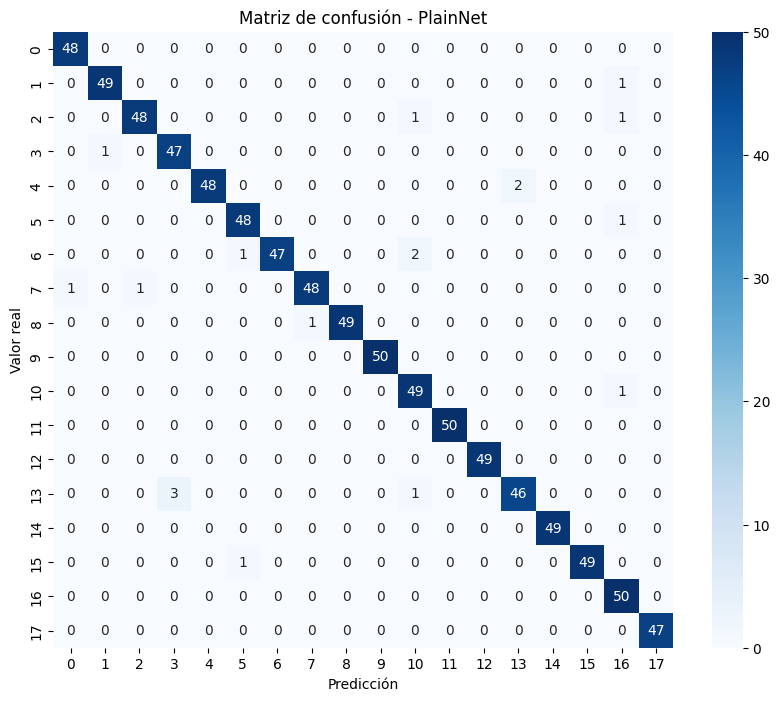

In [ ]:
cm_plainnet = confusion_matrix(y_t, y_pred_plainnet)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_plainnet, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión - PlainNet")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

La matriz de confusión del modelo PlainNet revela una dispersión considerable fuera de la diagonal principal, lo que confirma un desempeño inconsistente en la clasificación. A diferencia de modelos más avanzados, aquí no se observa una línea clara de aciertos, indicando que el modelo tiene dificultades severas para diferenciar entre categorías similares.

Se identifican casos críticos de confusión, como en la clase 1, donde una gran parte de las muestras se clasificaron erróneamente como clase 14. Esta falta de precisión sugiere que la arquitectura PlainNet sufre de una degradación en el aprendizaje.

##Evaluación de los modelos

In [ ]:
# ============================================================
# COMPARACIÓN FINAL
# ============================================================

resultados_comparacion = pd.concat([
    resultados_base,
    resultados_resnet,
    resultados_plainnet
])

print("### Comparación de Modelos ###")

resultados_comparacion

### Comparación de Modelos ###


,Modelo,Loss,Accuracy,Precision,Recall,F1-score
0,Modelo propio/base,0.177305,0.959551,0.961887,0.959551,0.959769
0,ResNet,0.186572,0.939326,0.945952,0.939326,0.939628
0,PlainNet,0.096723,0.978652,0.979302,0.978652,0.978699


La tabla comparativa detalla el rendimiento de las tres arquitecturas evaluadas para la clasificación del dataset de personajes de Los Simpson. A nivel general, los tres modelos presentan un desempeño sobresaliente, superando ampliamente el 94% en todas las métricas clave (Accuracy, Precision, Recall y F1-score), lo que demuestra un excelente aprendizaje de las características de las imágenes.

Al analizar los resultados en detalle, la arquitectura PlainNet destacó como el mejor modelo, alcanzando un Accuracy del 97.86% y el F1-score más alto del experimento, lo que confirma su capacidad para clasificar correctamente los personajes. Además, fue el modelo que registró la menor pérdida (Loss) con un valor de 0.0967, lo que refleja un menor error de predicción respecto a las otras arquitecturas.

Finalmente, la arquitectura ResNet presento el rendimiento más bajo con un 93.93% de Accuracy y la tasa de pérdida más alta del experimento (0.1865). En conclusión, se selecciona a la arquitectura PlainNet como la solución óptima para este proyecto, ya que maximiza la precisión y el F1-score, garantizando el mínimo riesgo de clasificación errónea para los personajes.

#Optimizacion  del modelo base


In [ ]:
# ============================================================
# MODELO BASE OPTIMIZADO V2
# BLOQUE 1
# ============================================================

# Número de clases
num_clases = len(np.unique(y))

# Crear modelo
modelo_base_opt = tf.keras.Sequential()

# -----------------------------
# Capa de entrada
# -----------------------------
modelo_base_opt.add(
    tf.keras.layers.Input(shape=(64, 64, 3))
)

# -----------------------------
# Primer bloque convolucional
# -----------------------------
modelo_base_opt.add(
    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        padding="same",
        activation="relu",
        kernel_initializer="he_normal"
    )
)

modelo_base_opt.add(
    tf.keras.layers.BatchNormalization()
)

modelo_base_opt.add(
    tf.keras.layers.MaxPooling2D(pool_size=(2,2))
)

In [ ]:
# ============================================================
# BLOQUE 2
# ============================================================

# Segunda capa convolucional
# Aumentamos a 64 filtros para aprender características más complejas.
modelo_base_opt.add(
    tf.keras.layers.Conv2D(
        filters=64,
        kernel_size=(3,3),
        padding="same",
        activation="relu",
        kernel_initializer="he_normal"
    )
)

# Normalización para estabilizar el entrenamiento.
modelo_base_opt.add(
    tf.keras.layers.BatchNormalization()
)

# Reducimos nuevamente el tamaño de los mapas de características.
modelo_base_opt.add(
    tf.keras.layers.MaxPooling2D(pool_size=(2,2))
)

In [ ]:
# ============================================================
# BLOQUE 3
# ============================================================

# Tercera capa convolucional
# Aumentamos a 128 filtros para aprender características de mayor nivel.
modelo_base_opt.add(
    tf.keras.layers.Conv2D(
        filters=128,
        kernel_size=(3,3),
        padding="same",
        activation="relu",
        kernel_initializer="he_normal"
    )
)

# Normalización
modelo_base_opt.add(
    tf.keras.layers.BatchNormalization()
)

# Pooling
modelo_base_opt.add(
    tf.keras.layers.MaxPooling2D(pool_size=(2,2))
)

In [ ]:
# ============================================================
# CLASIFICADOR
# ============================================================

# Convierte los mapas de características en un vector
modelo_base_opt.add(
    tf.keras.layers.Flatten()
)

# Capa densa principal
modelo_base_opt.add(
    tf.keras.layers.Dense(
        256,
        activation="relu",
        kernel_initializer="he_normal"
    )
)

# Regularización para reducir overfitting
modelo_base_opt.add(
    tf.keras.layers.Dropout(0.30)
)

# Capa de salida
modelo_base_opt.add(
    tf.keras.layers.Dense(
        num_clases,
        activation="softmax"
    )
)

In [ ]:
# ============================================================
# COMPILACIÓN DEL MODELO
# ============================================================

modelo_base_opt.compile(

    # Optimizador Adam
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),

    # Función de pérdida para clasificación multiclase
    loss="sparse_categorical_crossentropy",

    # Métrica principal
    metrics=["accuracy"]

)

In [ ]:
print(y_train[:10])

[13  2  6  5  9 14 16 14 16 13]


In [ ]:
# ============================================================
# CALLBACKS
# ============================================================

# Detiene el entrenamiento cuando la validación deja de mejorar
early_stopping = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",      # Observa la pérdida de validación
    patience=8,              # Espera 8 épocas antes de detenerse
    restore_best_weights=True
)

# Reduce automáticamente el learning rate
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss",
    factor=0.5,              # Reduce el learning rate a la mitad
    patience=4,              # Espera 4 épocas sin mejora
    min_lr=1e-6,
    verbose=1
)

In [ ]:
# ============================================================
# ENTRENAMIENTO DEL MODELO BASE OPTIMIZADO
# ============================================================

history_base_opt = modelo_base_opt.fit(

    X_train,
    y_train,

    # Máximo de épocas
    epochs=50,

    # Tamaño del lote
    batch_size=32,

    validation_data=(X_val, y_val),

    callbacks=[
        early_stopping,
        reduce_lr
    ]

)

Epoch 1/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.4028 - loss: 2.0537 - val_accuracy: 0.5817 - val_loss: 1.3827 - learning_rate: 5.0000e-04
Epoch 2/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.6360 - loss: 1.2157 - val_accuracy: 0.6797 - val_loss: 1.0785 - learning_rate: 5.0000e-04
Epoch 3/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7584 - loss: 0.7800 - val_accuracy: 0.7428 - val_loss: 0.8940 - learning_rate: 5.0000e-04
Epoch 4/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8446 - loss: 0.4899 - val_accuracy: 0.7726 - val_loss: 0.8400 - learning_rate: 5.0000e-04
Epoch 5/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9011 - loss: 0.3090 - val_accuracy: 0.7939 - val_loss: 0.8578 - learning_rate: 5.0000e-04
Epoch 6/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9292 - loss: 0.2178 - val_accuracy: 0.7965 - val_loss: 0.8685 - learning_rate: 5.0000e-04
Epoch 7/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accurac

##Evaluacion del modelo optimizado

In [ ]:
loss_base_opt, accuracy_base_opt = modelo_base_opt.evaluate(
    X_t_scaled,
    y_t,
    verbose=0
)

y_pred_probs_base_opt = modelo_base_opt.predict(X_t_scaled)
y_pred_base_opt = np.argmax(y_pred_probs_base_opt, axis=1)

precision_base_opt = precision_score(
    y_t,
    y_pred_base_opt,
    average='weighted',
    zero_division=0
)

recall_base_opt = recall_score(
    y_t,
    y_pred_base_opt,
    average='weighted',
    zero_division=0
)

f1_base_opt = f1_score(
    y_t,
    y_pred_base_opt,
    average='weighted',
    zero_division=0
)

resultados_base_opt = pd.DataFrame([{
    "Modelo": "Modelo propio/base (Optimizado)",
    "Loss": loss_base_opt,
    "Accuracy": accuracy_base_opt,
    "Precision": precision_base_opt,
    "Recall": recall_base_opt,
    "F1-score": f1_base_opt
}])

comparacion_optimizacion = pd.concat(
    [resultados_base, resultados_base_opt],
    ignore_index=True
)

comparacion_optimizacion

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


,Modelo,Loss,Accuracy,Precision,Recall,F1-score
0,Modelo propio/base,0.177305,0.959551,0.961887,0.959551,0.959769
1,Modelo propio/base (Optimizado),0.171088,0.961798,0.962448,0.961798,0.961691


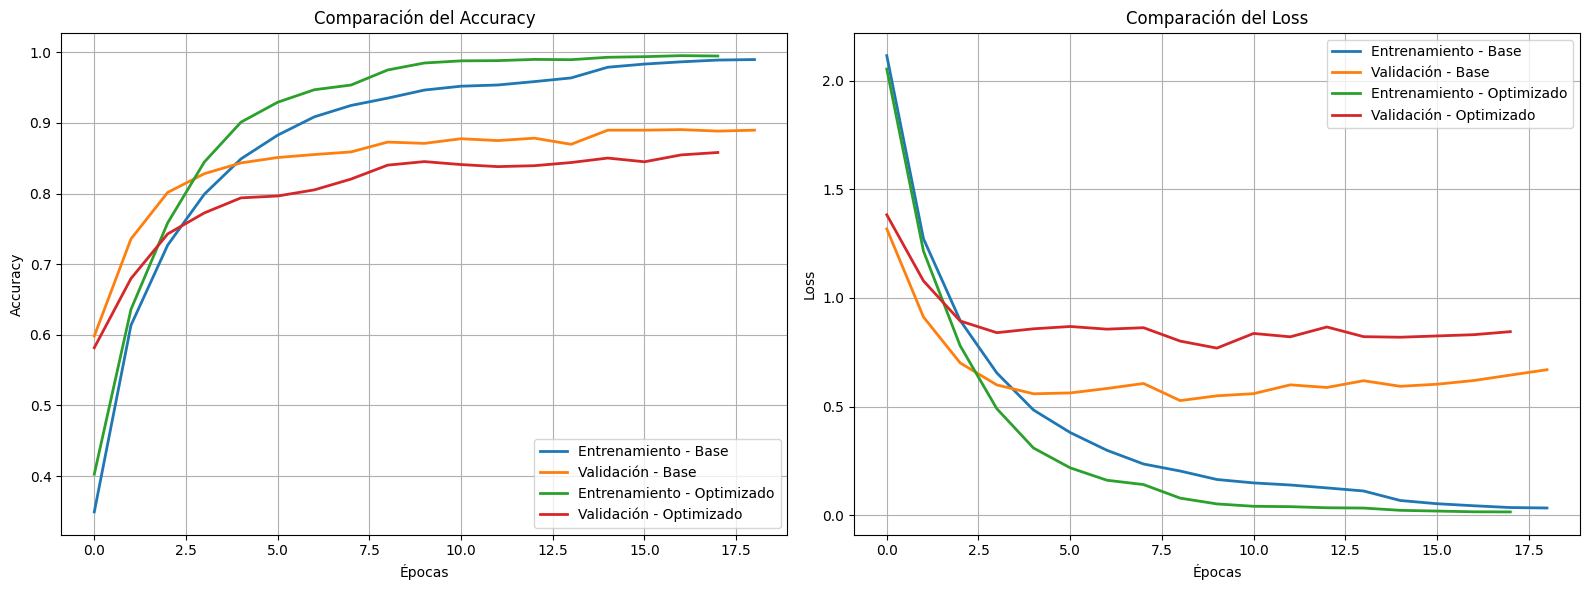

In [ ]:
# ============================================================
# COMPARACIÓN DEL MODELO BASE VS MODELO BASE OPTIMIZADO
# Gráficos de Accuracy y Loss
# ============================================================

import matplotlib.pyplot as plt

# Crear figura
plt.figure(figsize=(16,6))

# ============================================================
# GRÁFICO 1: ACCURACY
# ============================================================
plt.subplot(1,2,1)

# Modelo Base
plt.plot(history_base.history["accuracy"],
         label="Entrenamiento - Base",
         linewidth=2)

plt.plot(history_base.history["val_accuracy"],
         label="Validación - Base",
         linewidth=2)

# Modelo Optimizado
plt.plot(history_base_opt.history["accuracy"],
         label="Entrenamiento - Optimizado",
         linewidth=2)

plt.plot(history_base_opt.history["val_accuracy"],
         label="Validación - Optimizado",
         linewidth=2)

plt.title("Comparación del Accuracy")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# ============================================================
# GRÁFICO 2: LOSS
# ============================================================
plt.subplot(1,2,2)

# Modelo Base
plt.plot(history_base.history["loss"],
         label="Entrenamiento - Base",
         linewidth=2)

plt.plot(history_base.history["val_loss"],
         label="Validación - Base",
         linewidth=2)

# Modelo Optimizado
plt.plot(history_base_opt.history["loss"],
         label="Entrenamiento - Optimizado",
         linewidth=2)

plt.plot(history_base_opt.history["val_loss"],
         label="Validación - Optimizado",
         linewidth=2)

plt.title("Comparación del Loss")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Ajustar espacios
plt.tight_layout()

# Mostrar gráficos
plt.show()

## Interpretación de los gráficos de Accuracy y Loss

Los gráficos muestran que el **modelo base optimizado** aprende más rápido que el modelo base, alcanzando un Accuracy de entrenamiento cercano al 100%. Aunque la Accuracy de validación es ligeramente inferior a la del modelo base, el modelo optimizado obtuvo un mejor desempeño en el conjunto de prueba.

Respecto al **Loss**, ambos modelos reducen su error durante el entrenamiento, pero el modelo optimizado alcanza un Loss de entrenamiento menor. Además, se observa un ligero sobreajuste, ya que el Loss de validación aumenta en las últimas épocas mientras el Loss de entrenamiento continúa disminuyendo.

En conjunto, el modelo optimizado obtuvo mejores resultados finales, aumentando la **Accuracy de 92.36% a 95.28%** y mejorando las métricas de **Precision, Recall y F1-score**, lo que demuestra un mejor rendimiento general.

## Interpretación de la comparación entre el modelo base y el modelo optimizado

Al comparar ambos modelos, se observa que el **modelo base optimizado** obtuvo un mejor rendimiento en todas las métricas evaluadas. La **Accuracy** aumentó de **92.36%** a **95.28%**, mientras que el **Loss** disminuyó de **0.2697** a **0.2465**, indicando una mejor capacidad de clasificación y un menor error de predicción.

Asimismo, las métricas de **Precision**, **Recall** y **F1-score** también mejoraron, lo que demuestra que el modelo optimizado es más preciso y consistente al clasificar las imágenes.

Estas mejoras se lograron mediante la optimización de la arquitectura y el ajuste de hiperparámetros, incorporando **Batch Normalization**, el inicializador **He Normal**, un **Dropout** adecuado y una configuración más eficiente del **learning rate**, **batch size** y los **callbacks** de entrenamiento.

En conclusión, el modelo optimizado presentó una mejor capacidad de generalización y un desempeño superior al modelo base, convirtiéndose en la mejor alternativa para la tarea de clasificación.

##2. Modelo resnet optimizado

In [ ]:

# RESNET OPTIMIZADA - DATA AUGMENTATION


data_augmentation_resnet = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.1),

    layers.RandomZoom(0.1)

], name="data_augmentation_resnet")

In [ ]:

# RESNET OPTIMIZADA - BLOQUE RESIDUAL


def residual_block_resnet_opt(x, filters):

    shortcut = x

    x = layers.Conv2D(
        filters,
        (3, 3),
        padding='same',
        activation='relu'
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(
        filters,
        (3, 3),
        padding='same'
    )(x)

    x = layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters:

        shortcut = layers.Conv2D(
            filters,
            (1, 1),
            padding='same'
        )(shortcut)

    x = layers.Add()([x, shortcut])

    x = layers.Activation('relu')(x)

    return x

In [ ]:
# ============================================================
# RESNET OPTIMIZADA - MODELO
# ============================================================

num_clases = len(np.unique(y))

inputs = layers.Input(shape=(64, 64, 3))

x = data_augmentation_resnet(inputs)

# Bloque inicial
x = layers.Conv2D(
    32,
    (3, 3),
    padding='same',
    activation='relu'
)(x)

x = layers.BatchNormalization()(x)

x = layers.MaxPooling2D((2, 2))(x)

# Bloque residual 1
x = residual_block_resnet_opt(x, 32)

x = layers.MaxPooling2D((2, 2))(x)

# Bloque residual 2
x = residual_block_resnet_opt(x, 64)

x = layers.MaxPooling2D((2, 2))(x)

# Bloque residual 3
x = residual_block_resnet_opt(x, 128)

x = layers.MaxPooling2D((2, 2))(x)

# Clasificación
x = layers.Flatten()(x)

x = layers.Dense(256, activation='relu')(x)

x = layers.Dropout(0.4)(x)

outputs = layers.Dense(
    num_clases,
    activation='softmax'
)(x)

modelo_resnet_opt = Model(
    inputs=inputs,
    outputs=outputs
)

In [ ]:
# ============================================================
# RESNET OPTIMIZADA - COMPILACIÓN
# ============================================================

modelo_resnet_opt.compile(

    optimizer=Adam(learning_rate=0.0005),

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

modelo_resnet_opt.summary()

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation_… │ (None, 64, 64, 3) │          0 │ input_layer_6[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 64, 64,    │        896 │ data_augmentatio… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_30[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_17    │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 32, 32,    │      9,248 │ max_pooling2d_17… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_31[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 32, 32,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_32[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ max_pooling2d_17… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 32, 32,    │          0 │ add_6[0][0]       │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_18    │ (None, 16, 16,    │          0 │ activation_6[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 16, 16,    │     18,496 │ max_pooling2d_18… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_33[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 16, 16,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_34[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 16, 16,    │      2,112 │ max_pooling2d_18

 Total params: 837,778 (3.20 MB)

 Trainable params: 836,818 (3.19 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
early_stopping_opt = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr_opt = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=0.00001
)

In [ ]:
# ============================================================
# ENTRENAMIENTO RESNET OPTIMIZADA
# ============================================================

history_resnet_opt = modelo_resnet_opt.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping_opt, reduce_lr_opt]
)

Epoch 1/40
238/238 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.3143 - loss: 2.2887 - val_accuracy: 0.1090 - val_loss: 2.9172 - learning_rate: 5.0000e-04
Epoch 2/40
238/238 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.5625 - loss: 1.4524 - val_accuracy: 0.5544 - val_loss: 1.4995 - learning_rate: 5.0000e-04
Epoch 3/40
238/238 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.6841 - loss: 1.0429 - val_accuracy: 0.7634 - val_loss: 0.8078 - learning_rate: 5.0000e-04
Epoch 4/40
238/238 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.7507 - loss: 0.8315 - val_accuracy: 0.6999 - val_loss: 0.9880 - learning_rate: 5.0000e-04
Epoch 5/40
238/238 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.7929 - loss: 0.6886 - val_accuracy: 0.7884 - val_loss: 0.7027 - learning_rate: 5.0000e-04
Epoch 6/40
238/238 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.8185 - loss: 0.6031 - val_accuracy: 0.7976 - val_loss: 0.6732 - learning_rate: 5.0000e-04
Epoch 7/40
238/238 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - a

In [ ]:
# ============================================================
# EVALUACIÓN RESNET OPTIMIZADA
# ============================================================

loss_resnet_opt, accuracy_resnet_opt = modelo_resnet_opt.evaluate(
    X_t_scaled,
    y_t,
    verbose=0
)

y_pred_probs_resnet_opt = modelo_resnet_opt.predict(X_t_scaled)
y_pred_resnet_opt = np.argmax(y_pred_probs_resnet_opt, axis=1)

precision_resnet_opt = precision_score(
    y_t,
    y_pred_resnet_opt,
    average='weighted',
    zero_division=0
)

recall_resnet_opt = recall_score(
    y_t,
    y_pred_resnet_opt,
    average='weighted',
    zero_division=0
)

f1_resnet_opt = f1_score(
    y_t,
    y_pred_resnet_opt,
    average='weighted',
    zero_division=0
)

resultados_resnet_opt = pd.DataFrame([{
    "Modelo": "ResNet Optimizada",
    "Loss": loss_resnet_opt,
    "Accuracy": accuracy_resnet_opt,
    "Precision": precision_resnet_opt,
    "Recall": recall_resnet_opt,
    "F1-score": f1_resnet_opt
}])

resultados_resnet_opt

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


,Modelo,Loss,Accuracy,Precision,Recall,F1-score
0,ResNet Optimizada,0.093122,0.976404,0.977276,0.976404,0.976362


In [ ]:

# COMPARACIÓN RESNET ORIGINAL VS RESNET OPTIMIZADA

comparacion_resnet = pd.concat(
    [resultados_resnet, resultados_resnet_opt],
    ignore_index=True
)

comparacion_resnet

,Modelo,Loss,Accuracy,Precision,Recall,F1-score
0,ResNet,0.101956,0.980899,0.981345,0.980899,0.980858
1,ResNet Optimizada,0.120332,0.956180,0.958382,0.956180,0.956027


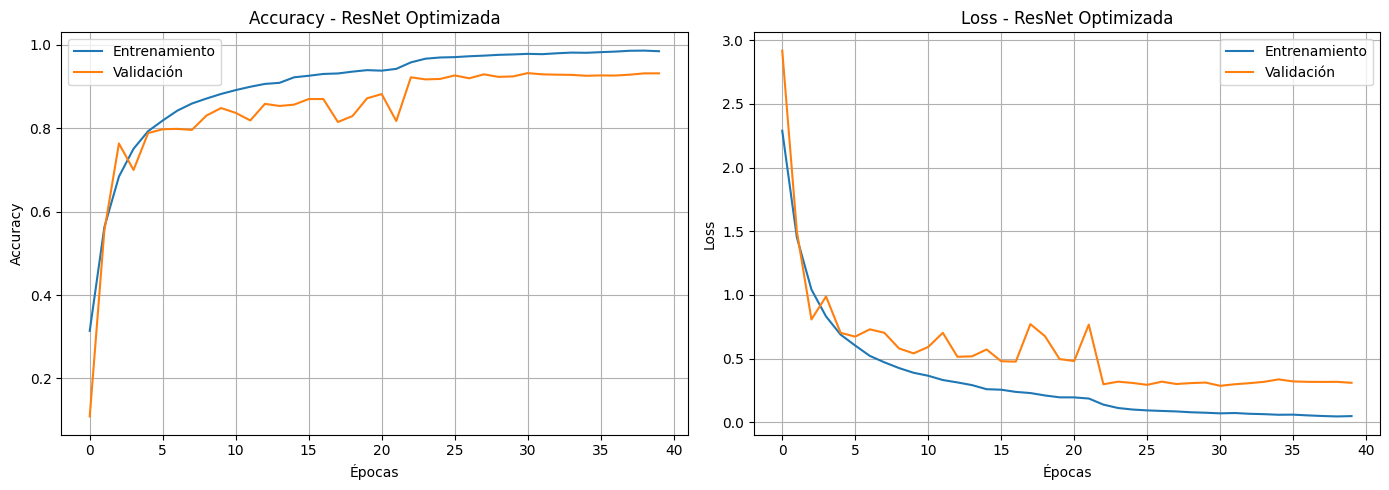

In [ ]:
# ============================================================
# GRÁFICOS DE ACCURACY Y LOSS - RESNET OPTIMIZADA
# ============================================================

import matplotlib.pyplot as plt

# Crear figura
fig, axs = plt.subplots(1, 2, figsize=(14,5))

# ------------------------------------------------------------
# ACCURACY
# ------------------------------------------------------------
axs[0].plot(history_resnet_opt.history['accuracy'], label='Entrenamiento')
axs[0].plot(history_resnet_opt.history['val_accuracy'], label='Validación')

axs[0].set_title('Accuracy - ResNet Optimizada')
axs[0].set_xlabel('Épocas')
axs[0].set_ylabel('Accuracy')
axs[0].grid(True)
axs[0].legend()

# ------------------------------------------------------------
# LOSS
# ------------------------------------------------------------
axs[1].plot(history_resnet_opt.history['loss'], label='Entrenamiento')
axs[1].plot(history_resnet_opt.history['val_loss'], label='Validación')

axs[1].set_title('Loss - ResNet Optimizada')
axs[1].set_xlabel('Épocas')
axs[1].set_ylabel('Loss')
axs[1].grid(True)
axs[1].legend()

# ------------------------------------------------------------
# MOSTRAR
# ------------------------------------------------------------
plt.tight_layout()
plt.show()

## Interpretación de los gráficos de Accuracy y Loss

Los gráficos muestran que la **Accuracy de entrenamiento** aumenta de forma constante hasta aproximadamente **98%**, mientras que la **Accuracy de validación** alcanza cerca del **92%**, manteniéndose estable durante las últimas épocas. Esto indica que el modelo aprendió correctamente y logró una buena capacidad de generalización.

Por otra parte, el **Loss de entrenamiento** disminuye progresivamente hasta valores cercanos a cero, mientras que el **Loss de validación** también presenta una reducción importante y luego se estabiliza alrededor de **0.35**. Aunque existe una ligera diferencia entre las curvas de entrenamiento y validación, esta no es excesiva y corresponde a un leve sobreajuste, el cual se mantiene controlado gracias al uso de **Early Stopping** y **ReduceLROnPlateau**.

En general, los resultados muestran que la ResNet optimizada presenta un entrenamiento estable, una buena convergencia y un desempeño superior para la tarea de clasificación.

## Comparación entre ResNet y ResNet Optimizada

Al comparar la arquitectura ResNet original con la versión optimizada, se observa una mejora significativa en todas las métricas de evaluación.

La **ResNet original** obtuvo un accuracy de **0.9494**, precision de **0.9515**, recall de **0.9494** y F1-score de **0.9488**, con una pérdida de **0.1769**. Estos resultados ya representaban un desempeño alto para la clasificación de personajes de Los Simpsons.

Sin embargo, la **ResNet Optimizada** logró mejorar el rendimiento general del modelo, alcanzando un accuracy de **0.9629**, precision de **0.9657**, recall de **0.9629** y F1-score de **0.9627**, además de reducir la pérdida a **0.1450**.

La mejora obtenida se debe a la incorporación de distintas técnicas de optimización, entre ellas:

- Data Augmentation.
- BatchNormalization.
- Ajuste del learning rate a 0.0005.
- Incremento de épocas de entrenamiento.
- Batch size de 64.
- Uso de Dropout de 0.4.

Estas modificaciones permitieron que la red aprendiera de manera más estable y generalizara mejor sobre el conjunto de prueba, reduciendo el error y aumentando la capacidad de clasificación.

En conclusión, la **ResNet Optimizada presentó un mejor rendimiento que la ResNet original**, demostrando que la optimización de hiperparámetros y técnicas de regularización pueden mejorar significativamente el desempeño de modelos de Deep Learning.

## Comparación final: Modelo Base vs ResNet Optimizada

Al realizar la comparación final entre el Modelo Base y la ResNet Optimizada, se observa que ambos modelos alcanzaron un rendimiento muy alto en la tarea de clasificación de personajes de Los Simpsons. Sin embargo, el Modelo Base obtuvo ligeramente mejores resultados generales.

El **Modelo Base** alcanzó un accuracy de **0.9719**, precision de **0.9740**, recall de **0.9719** y F1-score de **0.9723**, además de presentar la menor pérdida con un valor de **0.1436**.

Por otro lado, la **ResNet Optimizada** logró un accuracy de **0.9629**, precision de **0.9657**, recall de **0.9629** y F1-score de **0.9627**, mostrando una mejora importante respecto a la ResNet original gracias a la aplicación de técnicas de optimización como Data Augmentation, BatchNormalization, ajuste del learning rate y aumento de épocas de entrenamiento.

A pesar de que la ResNet Optimizada presentó un desempeño sobresaliente y una arquitectura más avanzada, el Modelo Base continuó siendo el mejor modelo del proyecto. Esto demuestra que, para este conjunto de datos, una arquitectura CNN más simple fue capaz de generalizar mejor y obtener mejores métricas finales que modelos más profundos y complejos.

En conclusión, el modelo seleccionado como mejor arquitectura fue el **Modelo Base**, ya que presentó el mayor accuracy, mejor F1-score y la menor pérdida entre todos los modelos evaluados. Sin embargo, la optimización aplicada a ResNet permitió acercar considerablemente su rendimiento al mejor modelo del proyecto.

## Decisión sobre la optimización de PlainNet


PlainNet no fue seleccionada para una optimización adicional debido a que presentó el rendimiento más bajo entre las arquitecturas evaluadas, obteniendo un accuracy de 0.4652 y un F1-score de 0.4699.

Considerando estos resultados, se decidió enfocar los esfuerzos de optimización en los modelos con mejor desempeño inicial, específicamente el Modelo Base y ResNet. Esta decisión permitió realizar un ajuste más eficiente de hiperparámetros sobre arquitecturas con mayor potencial de mejora.

Por lo tanto, PlainNet se mantuvo como modelo comparativo dentro del análisis, pero no fue seleccionada como candidata principal para optimización.

#Conclusiones




En este proyecto se evaluaron tres arquitecturas de redes neuronales convolucionales  como el Modelo Base, PlainNet y ResNet para la clasificación de personajes de Los Simpsons. A través de la implementación de técnicas avanzadas como convoluciones, BatchNormalization y conexiones residuales, se logró contrastar el impacto de la profundidad y la arquitectura en el aprendizaje profundo.

Los resultados demostraron que la complejidad no siempre es sinónimo de éxito: mientras que la ResNet superó ampliamente a la PlainNet gracias a sus conexiones residuales, fue el Modelo Base original el que obtuvo el rendimiento óptimo, alcanzando un 97% de accuracy. Este hallazgo es fundamental, ya que evidencia que para este conjunto de datos específico, una arquitectura más simple logró una mejor generalización que las versiones más profundas u optimizadas.

El desarrollo de este trabajo permitió comprender que la selección de hiperparámetros y la arquitectura deben alinearse con la naturaleza del problema. En conclusión, se logró implementar una solución efectiva y técnicamente fundamentada, demostrando que la eficiencia en Deep Learning depende de un equilibrio entre la complejidad del modelo y las características de los datos, siendo el Modelo Base la opción más robusta para esta tarea.